# Level 2: Task 2 - Customer Preference Analysis

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
# Load the dataset
df = pd.read_csv('../../level1/task2/cleaned_data.csv')

In [ ]:
# Display Aggregate rating unique values
df['Aggregate rating'].unique()

array([4.8, 4.5, 4.4, 4.9, 4. , 4.2, 4.3, 3.6, 4.7, 3. , 3.8, 3.7, 3.2,
       3.1, 0. , 4.1, 3.3, 4.6, 3.9, 3.4, 3.5, 2.2, 2.9, 2.4, 2.6, 2.8,
       2.1, 2.7, 2.5, 1.8, 2. , 2.3, 1.9])

In [ ]:
# Display Cuisines unique values and its total
print(df['Cuisines'].unique())
print(df['Cuisines'].nunique())

['French, Japanese, Desserts' 'Japanese'
 'Seafood, Asian, Filipino, Indian' ... 'Burger, Izgara'
 'World Cuisine, Patisserie, Cafe' 'Italian, World Cuisine']
1826


In [ ]:
# Split and explode Cuisines
df['Cuisines'] = df['Cuisines'].apply(lambda x: [i.strip() for i in x.split(',')])
df = df.explode('Cuisines')

In [ ]:
# Display Cuisines unique values and its total after split and explode
print(df['Cuisines'].unique())
print(df['Cuisines'].nunique())

['French' 'Japanese' 'Desserts' 'Seafood' 'Asian' 'Filipino' 'Indian'
 'Sushi' 'Korean' 'Chinese' 'European' 'Mexican' 'American' 'Ice Cream'
 'Cafe' 'Italian' 'Pizza' 'Bakery' 'Mediterranean' 'Fast Food' 'Brazilian'
 'Arabian' 'Bar Food' 'Grill' 'International' 'Peruvian' 'Latin American'
 'Burger' 'Juices' 'Healthy Food' 'Beverages' 'Lebanese' 'Sandwich'
 'Steak' 'BBQ' 'Gourmet Fast Food' 'Mineira' 'North Eastern' 'Unknown'
 'Coffee and Tea' 'Vegetarian' 'Tapas' 'Breakfast' 'Diner' 'Southern'
 'Southwestern' 'Spanish' 'Argentine' 'Caribbean' 'German' 'Vietnamese'
 'Thai' 'Modern Australian' 'Teriyaki' 'Cajun' 'Canadian' 'Tex-Mex'
 'Middle Eastern' 'Greek' 'Bubble Tea' 'Tea' 'Australian' 'Fusion' 'Cuban'
 'Hawaiian' 'Salad' 'Irish' 'New American' 'Soul Food' 'Turkish'
 'Pub Food' 'Persian' 'Continental' 'Singaporean' 'Malay' 'Cantonese'
 'Dim Sum' 'Western' 'Finger Food' 'British' 'Deli' 'Indonesian'
 'North Indian' 'Mughlai' 'Biryani' 'South Indian' 'Pakistani' 'Afghani'
 'Hyderabadi

In [9]:
# Define mapping of corrupted to correct cuisine names
fix_cuisine_name = {
    'D�_ner': 'Döner',
    'B�_rek': 'Börek'
}

# Replace the corrupted names
df['Cuisines'] = df['Cuisines'].replace(fix_cuisine_name)

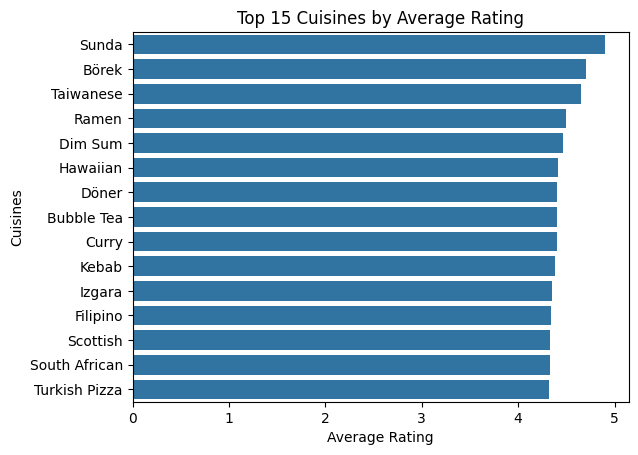

In [11]:
# Cuisine vs. Average Rating
cuisine_rating = df.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False)

sns.barplot(x=cuisine_rating.head(15), y=cuisine_rating.head(15).index)
plt.title('Top 15 Cuisines by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Cuisines')
plt.show()

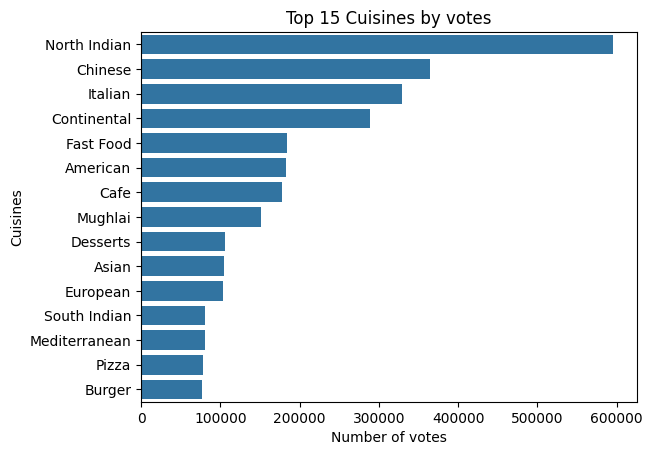

In [12]:
# Cuisines vs. Number of votes
cuisine_vote = df.groupby('Cuisines')['Votes'].sum().sort_values(ascending=False)

sns.barplot(x=cuisine_vote.head(15), y=cuisine_vote.head(15).index)
plt.title('Top 15 Cuisines by votes')
plt.xlabel('Number of votes')
plt.ylabel('Cuisines')
plt.show()

In [ ]:
# Cuisine vs Votes (Popularity)
cuisine_summary = df.groupby('Cuisines').agg({
    'Aggregate rating': 'mean',
    'Votes': 'sum'
}).reset_index()

# Sctter plot using plotly
fig = px.scatter(
    cuisine_summary,
    x='Aggregate rating',
    y='Votes',
    color='Cuisines',
    hover_name='Cuisines',
    title='Cuisine Rating vs Popularity (Votes)',
    width=800,
    height=500
)

# Remove axis labels and gridlines
fig.update_layout(
    showlegend=False,  # Hide the color legend (optional)
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False)
)

fig.show()
